# 03 · Análisis del corpus

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from corpus import AUDITORIA, MANIFIESTO, METADATA, PROCESADO, leerCsv

SPLITS = ("train", "test", "validate")
NUMERICAS = ("nitidez", "brillo", "fracSaturados", "fracNegros", "ladoOriginal",
             "ancho", "alto", "x1", "y1", "x2", "y2", "confianza")

manifiesto = json.loads(MANIFIESTO.read_text())
aud = pd.DataFrame(leerCsv(AUDITORIA))
for col in NUMERICAS:
    aud[col] = pd.to_numeric(aud[col], errors="coerce")

archivos = {a for sp in manifiesto["reparto"].values() for s in SPLITS for a in sp[s]}
aceptadas = aud[aud.veredicto == "aceptada"]

print(f"{manifiesto['creado'][:10]} · {manifiesto['notas']}")
print(f"{manifiesto['num_clases']} clases · {manifiesto['conteos']['total']:,} imágenes")
print(json.dumps(manifiesto["parametros"], ensure_ascii=False, indent=2))

2026-10-07 · Dataset de mariposas con lista de especies obtenida de iNaturalist en vez del Mariposario, más imágenes por especie
100 clases · 25,306 imágenes
{
  "umbrales": {
    "nitidez": 60.0,
    "fracSaturados": 0.06,
    "fracNegros": 0.2,
    "ladoOriginal": 200
  },
  "minimo_por_especie": 40,
  "semilla": 42,
  "lado_salida": 448
}


## 1 · Del original al recorte

      ancho    alto  ladoOriginal  fracConservada
min   100.0    75.0          28.0            0.01
25%   839.0   683.0         411.0            0.26
50%  1024.0   768.0         576.0            0.50
75%  1024.0   922.0         715.0            0.70
max  1024.0  1024.0        1024.0            1.00

salida 448px · ampliadas 10,036 (29.8%) · reducidas 23,593


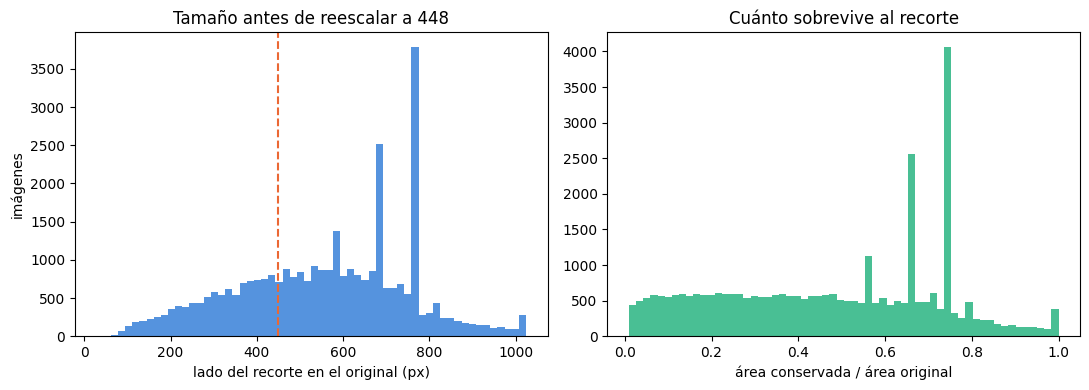

In [3]:
vivas = aud.dropna(subset=["ladoOriginal"]).copy()
vivas["areaOriginal"] = vivas.ancho * vivas.alto
vivas["fracConservada"] = vivas.ladoOriginal ** 2 / vivas.areaOriginal
lado = manifiesto["parametros"]["lado_salida"]

print(vivas[["ancho", "alto", "ladoOriginal", "fracConservada"]]
      .describe().loc[["min", "25%", "50%", "75%", "max"]].round(2).to_string())
print(f"\nsalida {lado}px · ampliadas {(vivas.ladoOriginal < lado).sum():,} "
      f"({(vivas.ladoOriginal < lado).mean():.1%}) · "
      f"reducidas {(vivas.ladoOriginal > lado).sum():,}")

fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
ejes[0].hist(vivas.ladoOriginal, bins=60, color="#2a78d6", alpha=0.8)
ejes[0].axvline(lado, color="#eb6834", linestyle="--")
ejes[0].set(xlabel="lado del recorte en el original (px)", ylabel="imágenes",
            title=f"Tamaño antes de reescalar a {lado}")
ejes[1].hist(vivas.fracConservada, bins=60, color="#1baf7a", alpha=0.8)
ejes[1].set(xlabel="área conservada / área original", title="Cuánto sobrevive al recorte")
fig.tight_layout()
plt.show()

## 2 · Qué se descarta

In [4]:
motivos = aud[aud.veredicto == "descartada"].motivo.value_counts()
descartes = pd.DataFrame({"imagenes": motivos,
                          "% del total": (100 * motivos / len(aud)).round(2),
                          "% de descartes": (100 * motivos / motivos.sum()).round(2)})

print(f"{len(aud):,} candidatas → {len(aceptadas):,} aceptadas "
      f"({len(aceptadas) / len(aud):.1%}) → {len(archivos):,} en el manifiesto")
if len(aceptadas) != len(archivos):
    print(f"  descuadre de {abs(len(aceptadas) - len(archivos))} entre auditoría y manifiesto")
descartes

34,804 candidatas → 25,306 aceptadas (72.7%) → 25,306 en el manifiesto


,imagenes,% del total,% de descartes
motivo,,,
sobreexpuesta,4130,11.87,43.48
recorte_pequeno,1468,4.22,15.46
desenfocada,1287,3.70,13.55
casi_duplicado,1212,3.48,12.76
sin_deteccion,1125,3.23,11.84
subexpuesta,276,0.79,2.91


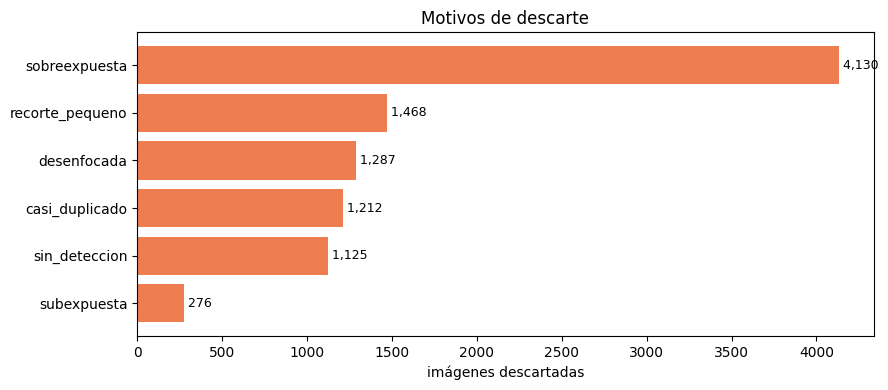

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(motivos.index[::-1], motivos.values[::-1], color="#eb6834", alpha=0.85)
for i, v in enumerate(motivos.values[::-1]):
    ax.text(v, i, f" {v:,}", va="center", fontsize=9)
ax.set(xlabel="imágenes descartadas", title="Motivos de descarte")
fig.tight_layout()
plt.show()

In [6]:
porEspecie = aud.groupby("especie").veredicto.value_counts().unstack(fill_value=0)
porEspecie["tasa_descarte"] = (porEspecie.get("descartada", 0) /
                               porEspecie.sum(axis=1)).round(3)
porEspecie.nlargest(12, "tasa_descarte")

veredicto,aceptada,descartada,tasa_descarte
especie,,,
dryas_iulia,184,166,0.474
heliconius_erato,195,155,0.443
dione_juno,207,143,0.409
hamadryas_feronia,213,137,0.391
morpho_helenor,215,135,0.386
dione_vanillae,216,134,0.383
anteos_clorinde,217,133,0.380
dione_moneta,219,130,0.372
catonephele_numilia,221,129,0.369


## 3 · Calidad frente a los umbrales

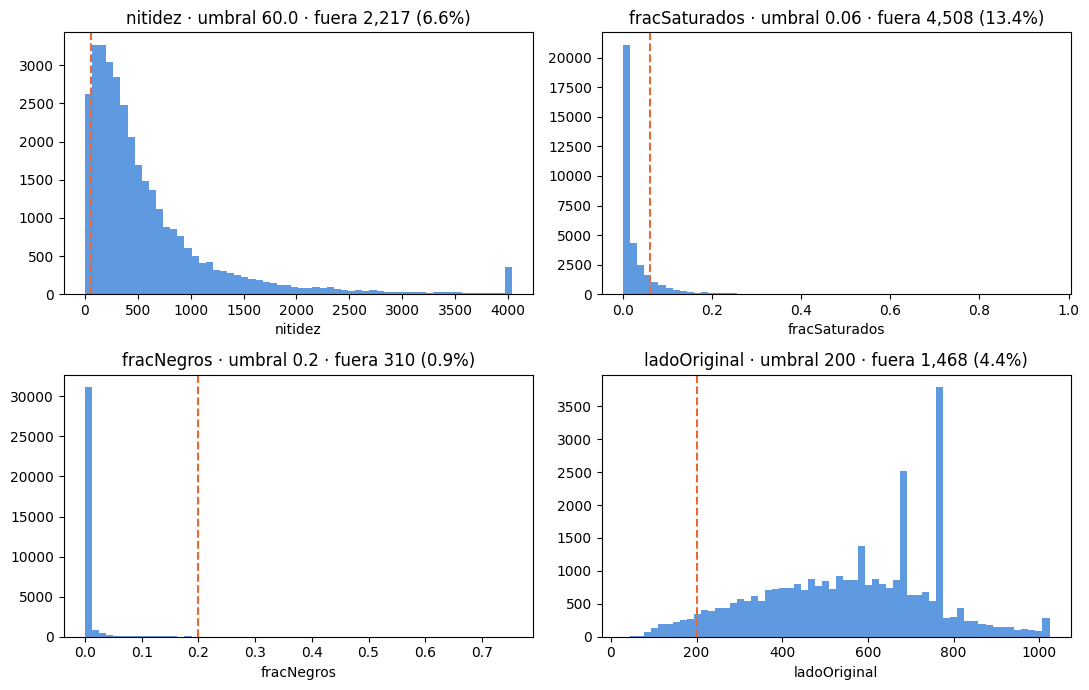

In [7]:
umbrales = manifiesto["parametros"]["umbrales"]
MENOR_DESCARTA = {"nitidez", "ladoOriginal"}

fig, ejes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (col, umbral) in zip(ejes.ravel(), umbrales.items()):
    serie = vivas[col]
    recorte = serie.quantile(0.99) if col == "nitidez" else serie.max()
    fuera = serie < umbral if col in MENOR_DESCARTA else serie > umbral
    ax.hist(serie.clip(upper=recorte), bins=60, color="#2a78d6", alpha=0.75)
    ax.axvline(umbral, color="#eb6834", linestyle="--", linewidth=1.5)
    ax.set(title=f"{col} · umbral {umbral} · fuera {fuera.sum():,} ({fuera.mean():.1%})",
           xlabel=col)
fig.tight_layout()
plt.show()

In [8]:
filas = []
for col, umbral in umbrales.items():
    for factor in (0.5, 0.75, 1.0, 1.5, 2.0):
        nuevo = umbral * factor
        fuera = vivas[col] < nuevo if col in MENOR_DESCARTA else vivas[col] > nuevo
        filas.append({"metrica": col, "umbral": round(nuevo, 3), "factor": factor,
                      "descartaria": int(fuera.sum())})
pd.DataFrame(filas).pivot(index="metrica", columns="factor", values="descartaria")

factor,0.50,0.75,1.00,1.50,2.00
metrica,,,,,
fracNegros,597,430,310,173,103
fracSaturados,8652,6205,4508,2695,1690
ladoOriginal,118,681,1468,4075,7861
nitidez,1034,1621,2217,3614,5062


## 4 · Balance por clase

min         184.0
median      257.0
mean        253.1
max         304.0
sum       25306.0

desbalance max/min: 1.65x · Gini 0.051
mínimo por especie: 40


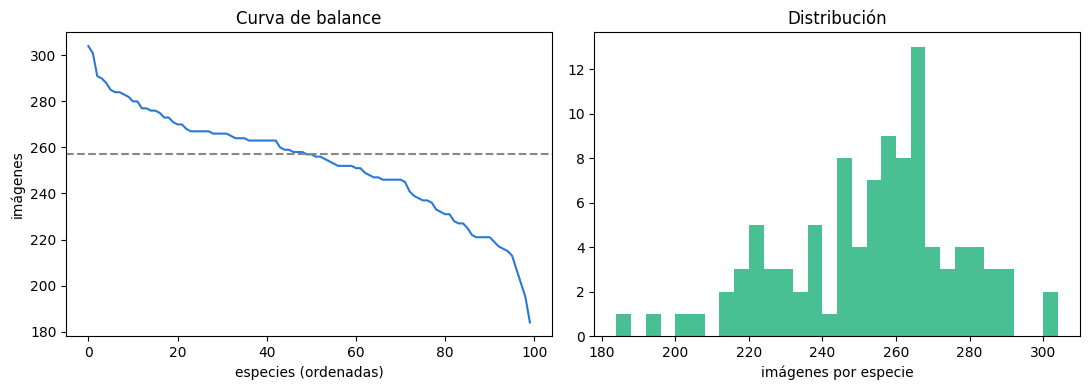

,imagenes
dryas_iulia,184
heliconius_erato,195
epargyreus_cruza,201
dione_juno,207
hamadryas_feronia,213
morpho_helenor,215
dione_vanillae,216
anteos_clorinde,217
dione_moneta,219
euptoieta_hegesia,221


In [9]:
porClase = pd.Series({e: sum(len(sp[s]) for s in SPLITS)
                      for e, sp in manifiesto["reparto"].items()}).sort_values()
gini = (2 * np.sum(np.arange(1, len(porClase) + 1) * porClase.values) /
        (len(porClase) * porClase.sum()) - (len(porClase) + 1) / len(porClase))

print(porClase.agg(["min", "median", "mean", "max", "sum"]).round(1).to_string())
print(f"\ndesbalance max/min: {porClase.max() / porClase.min():.2f}x · Gini {gini:.3f}")
print(f"mínimo por especie: {manifiesto['parametros']['minimo_por_especie']}")

fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
ejes[0].plot(porClase.values[::-1], color="#2a78d6")
ejes[0].axhline(porClase.median(), color="#8a8880", linestyle="--")
ejes[0].set(xlabel="especies (ordenadas)", ylabel="imágenes", title="Curva de balance")
ejes[1].hist(porClase.values, bins=30, color="#1baf7a", alpha=0.8)
ejes[1].set(xlabel="imágenes por especie", title="Distribución")
fig.tight_layout()
plt.show()

porClase.head(12).to_frame("imagenes")

## 5 · Splits

In [10]:
reparto = pd.DataFrame({s: {e: len(sp[s]) for e, sp in manifiesto["reparto"].items()}
                        for s in SPLITS})
proporcion = reparto.div(reparto.sum(axis=1), axis=0)

print(reparto.sum().to_frame("imagenes").assign(
    porcentaje=lambda d: (100 * d.imagenes / d.imagenes.sum()).round(1)).to_string())
print(f"\nproporción de train por especie: {proporcion.train.min():.3f} – "
      f"{proporcion.train.max():.3f}")

observacionDe = {m["archivo"]: m["observation_id"] for m in leerCsv(METADATA)}
enTrain = {observacionDe[a] for sp in manifiesto["reparto"].values()
           for a in sp["train"] if a in observacionDe}
evaluacion = [a for sp in manifiesto["reparto"].values() for s in ("test", "validate")
              for a in sp[s] if a in observacionDe]
fugadas = sum(1 for a in evaluacion if observacionDe[a] in enTrain)
print(f"fuga de observación entre train y evaluación: {fugadas:,}/{len(evaluacion):,}")

          imagenes  porcentaje
train        17716        70.0
test          5057        20.0
validate      2533        10.0

proporción de train por especie: 0.697 – 0.702
fuga de observación entre train y evaluación: 2,720/7,590


## 6 · Procedencia

In [11]:
meta = pd.DataFrame(leerCsv(METADATA)).drop_duplicates("photo_id")
usadas = meta[meta.archivo.isin(archivos)]

print(f"{len(usadas):,} fotos · {usadas.observation_id.nunique():,} observaciones "
      f"({len(usadas) / usadas.observation_id.nunique():.2f} fotos/obs)")
print(f"\nlicencias:\n{usadas.licencia.value_counts().to_string()}")
if usadas.quality_grade.any():
    print(f"\nquality_grade:\n{usadas.quality_grade.value_counts().to_string()}")
faltantes = len(archivos) - len(usadas)
if faltantes:
    print(f"\n{faltantes:,} archivos del manifiesto sin fila en metadata.csv")

25,305 fotos · 18,636 observaciones (1.36 fotos/obs)

licencias:
licencia
cc-by-nc       17995
cc-by           4137
cc-by-sa        1418
cc-by-nc-sa     1290
cc0              465

quality_grade:
quality_grade
research    24908
              397

1 archivos del manifiesto sin fila en metadata.csv


## 7 · Muestra

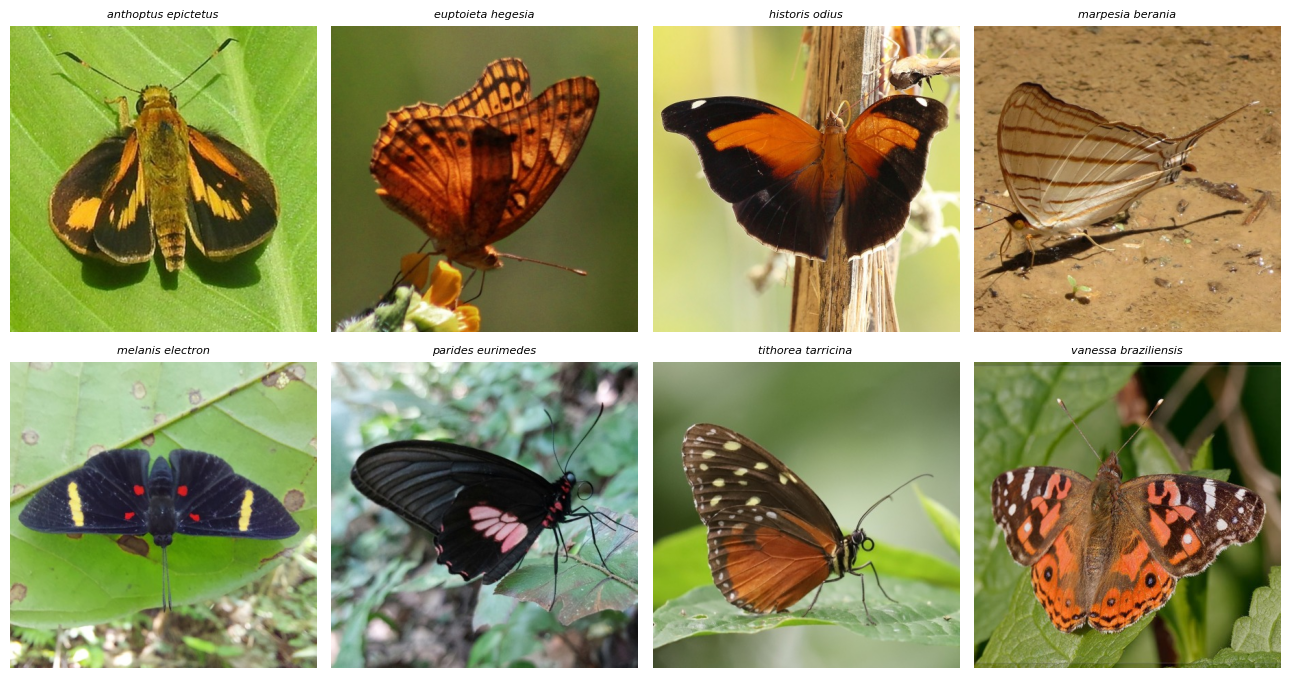

In [12]:
rng = np.random.default_rng(42)
especies = sorted(rng.choice(sorted(manifiesto["reparto"]), 8, replace=False))

fig, ejes = plt.subplots(2, 4, figsize=(13, 7))
for ax, especie in zip(ejes.ravel(), especies):
    archivo = manifiesto["reparto"][especie]["train"][0]
    ax.imshow(plt.imread(PROCESADO / especie / archivo))
    ax.set_title(especie.replace("_", " "), fontsize=8, style="italic")
    ax.axis("off")
fig.tight_layout()
plt.show()